In [1]:
import numpy as np
import numpy.linalg as la
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)
np.random.seed(42)
print('Setup complete. NumPy', np.__version__)

Setup complete. NumPy 2.0.2


In [2]:


scalar = np.array(5)
vector = np.array([2, 5, 1])
matrix = np.array([[1, 2], [3, 4]])
tensor = np.ones((3, 2, 2))
for name, arr in [('scalar', scalar), ('vector', vector),
                  ('matrix', matrix), ('tensor', tensor)]:
    print(f'{name:7s} ndim={arr.ndim}  shape={arr.shape}')


A = np.arange(6).reshape(2, 3)
B = np.ones((2, 3), dtype=int)

print('A:\n', A)
print('A + B (element-wise add):\n', A + B)
print('A.T  (transpose -> shape', A.T.shape, '):\n', A.T)
print('A.reshape(3, 2):\n', A.reshape(3, 2))
print('A.flatten():', A.flatten())


scalar  ndim=0  shape=()
vector  ndim=1  shape=(3,)
matrix  ndim=2  shape=(2, 2)
tensor  ndim=3  shape=(3, 2, 2)


In [3]:
T = np.arange(12).reshape(3, 4)
print("T:\n", T)

# 1. ndim and shape
print("ndim:", T.ndim)
print("shape:", T.shape)

# 2. T + T
print("T + T:\n", T + T)

# 3. Transpose (print .T.shape) and reshape to (2, 6)
print("Transpose shape:", T.T.shape)

T_reshaped = T.reshape(2, 6)
print("Reshaped T (2, 6):\n", T_reshaped)

T:
 [[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
ndim: 2
shape: (3, 4)
T + T:
 [[ 0  2  4  6]
 [ 8 10 12 14]
 [16 18 20 22]]
Transpose shape: (4, 3)
Reshaped T (2, 6):
 [[ 0  1  2  3  4  5]
 [ 6  7  8  9 10 11]]


In [4]:
a = np.array([1, 2, 3])
b = np.array([4, 0, 1])

print('a . b  (dot)   :', np.dot(a, b))

print('a x b  (cross) :', np.cross(a, b))


a . b  (dot)   : 7
a x b  (cross) : [ 2 11 -8]


In [5]:
print('L2 norm  ||a||_2 :', la.norm(a))
print('L1 norm  ||a||_1 :', la.norm(a, 1))
print('Linf norm        :', la.norm(a, np.inf))

def cosine(u, v):
    return np.dot(u, v) / (la.norm(u) * la.norm(v))

print('cosine(a, b)     :', round(cosine(a, b), 3))

L2 norm  ||a||_2 : 3.7416573867739413
L1 norm  ||a||_1 : 6.0
Linf norm        : 3.0
cosine(a, b)     : 0.454


In [7]:
pairs = [
    (np.array([1, 0, 1]), np.array([1, 0, 1])),
    (np.array([1, 2, 3]), np.array([3, 2, 1])),
    (np.array([2, 0, 0]), np.array([0, 5, 0])),
]

for i, (u, v) in enumerate(pairs, start=1):

    l1 = np.linalg.norm(u, ord=1)
    l2 = np.linalg.norm(u)

    cos_sim = cosine(u, v)

    print(f"Pair {i}:")
    print("L1 norm of u:", l1)
    print("L2 norm of u:", l2)
    print("Cosine similarity:", cos_sim)
    print()

Pair 1:
L1 norm of u: 2.0
L2 norm of u: 1.4142135623730951
Cosine similarity: 0.9999999999999998

Pair 2:
L1 norm of u: 6.0
L2 norm of u: 3.7416573867739413
Cosine similarity: 0.7142857142857143

Pair 3:
L1 norm of u: 2.0
L2 norm of u: 2.0
Cosine similarity: 0.0



In [8]:
A = np.array([[2., 1.],
              [1., 3.]])
B = np.array([[1., 0.],
              [4., 2.]])

print('A @ B (matrix multiply):\n', A @ B)
print('A.T   (transpose):\n', A.T)
print('inverse(A):\n', la.inv(A))
print('trace(A) = sum of diagonal:', np.trace(A))


A @ B (matrix multiply):
 [[ 6.  2.]
 [13.  6.]]
A.T   (transpose):
 [[2. 1.]
 [1. 3.]]
inverse(A):
 [[ 0.6 -0.2]
 [-0.2  0.4]]
trace(A) = sum of diagonal: 5.0


In [9]:

I = np.eye(2)
print('Identity I:\n', I)
print('A @ inv(A) == I ?', np.allclose(A @ la.inv(A), I))


print('A symmetric?', np.allclose(A, A.T))


theta = np.radians(30)
Q = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta),  np.cos(theta)]])
print('Q orthogonal?', np.allclose(Q.T @ Q, I))

Identity I:
 [[1. 0.]
 [0. 1.]]
A @ inv(A) == I ? True
A symmetric? True
Q orthogonal? True


In [10]:

M = np.array([[4., 2.],
              [2., 3.]])

P = np.array([[0., -1.],
              [1.,  0.]])

inv_M = np.linalg.inv(M)
trace_M = np.trace(M)

print("Inverse of M:\n", inv_M)
print("Trace of M:", trace_M)


identity = np.eye(M.shape[0])
print("M @ inv(M):\n", M @ inv_M)
print("Is M @ inv(M) equal to Identity?",
      np.allclose(M @ inv_M, identity))


print("Is M symmetric?", np.array_equal(M, M.T))
print("Is P orthogonal?",
      np.allclose(P.T @ P, np.eye(P.shape[0])))

Inverse of M:
 [[ 0.375 -0.25 ]
 [-0.25   0.5  ]]
Trace of M: 7.0
M @ inv(M):
 [[1. 0.]
 [0. 1.]]
Is M @ inv(M) equal to Identity? True
Is M symmetric? True
Is P orthogonal? True


In [11]:

square = np.array([[0, 1, 1, 0],
                   [0, 0, 1, 1]], dtype=float)

S = np.array([[1.5, 0.0],
              [0.0, 0.5]])


t = np.radians(30)
R = np.array([[np.cos(t), -np.sin(t)],
              [np.sin(t),  np.cos(t)]])

scaled  = S @ square
rotated = R @ square
print('Rotated corners:\n', rotated)


Rotated corners:
 [[ 0.     0.866  0.366 -0.5  ]
 [ 0.     0.5    1.366  0.866]]


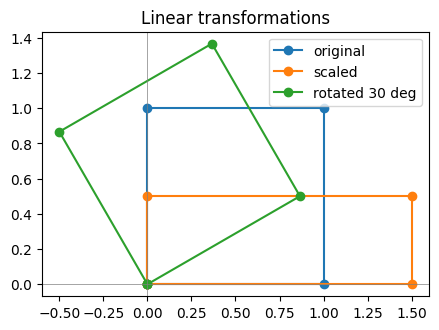

In [12]:
def close_loop(pts):

    return np.hstack([pts, pts[:, :1]])

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(*close_loop(square),  marker='o', label='original')
ax.plot(*close_loop(scaled),  marker='o', label='scaled')
ax.plot(*close_loop(rotated), marker='o', label='rotated 30 deg')
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
ax.set_aspect('equal'); ax.legend(); ax.set_title('Linear transformations')
plt.show()

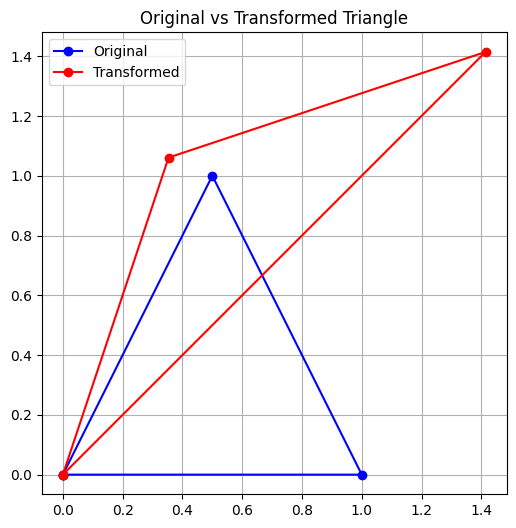

In [13]:
tri = np.array([[0, 1, 0.5],
                [0, 0, 1.0]])
def close_loop(points):
    return np.hstack((points, points[:, :1]))


S = np.array([[2, 0],
              [0, 0.5]])

theta = np.deg2rad(45)

R = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta),  np.cos(theta)]])


scaled = S @ tri
transformed = R @ scaled


tri_plot = close_loop(tri)
transformed_plot = close_loop(transformed)

plt.figure(figsize=(6, 6))
plt.plot(tri_plot[0], tri_plot[1], 'bo-', label='Original')
plt.plot(transformed_plot[0], transformed_plot[1], 'ro-', label='Transformed')

plt.axis('equal')
plt.grid(True)
plt.legend()
plt.title("Original vs Transformed Triangle")
plt.show()

In [14]:


A = np.array([[2., 0.],
              [0., 3.]])

vals, vecs = la.eig(A)
print('Eigenvalues  (lambda):', vals)
print('Eigenvectors (columns):\n', vecs)

Eigenvalues  (lambda): [2. 3.]
Eigenvectors (columns):
 [[1. 0.]
 [0. 1.]]


In [16]:
for i in range(len(vals)):
    v = vecs[:, i]
    lhs = A @ v
    rhs = vals[i] * v
    print(f'lambda={vals[i]:.1f}  A v == lambda v ?', np.allclose(lhs, rhs))

lambda=2.0  A v == lambda v ? True
lambda=3.0  A v == lambda v ? True


In [17]:
C = np.array([[4., 1.],
              [2., 3.]])


eigenvalues, eigenvectors = la.eig(C)


print("Eigenvalues:")
print(eigenvalues)

print("\nEigenvectors:")
print(eigenvectors)

v = eigenvectors[:, 0]
lam = eigenvalues[0]
print("\nC @ v:")
print(C @ v)

print("\nλ * v:")
print(lam * v)

print("\nVerification:", np.allclose(C @ v, lam * v))

Eigenvalues:
[5. 2.]

Eigenvectors:
[[ 0.707 -0.447]
 [ 0.707  0.894]]

C @ v:
[3.536 3.536]

λ * v:
[3.536 3.536]

Verification: True


In [18]:
A = np.array([[ 2.,  1., -1.],
              [-3., -1.,  2.],
              [-2.,  1.,  2.]])
b = np.array([8., -11., -3.])

x = la.solve(A, b)
print('Solution x:', x)
print('Rank of A :', la.matrix_rank(A))
print('Full rank -> a unique solution exists')

Solution x: [ 2.  3. -1.]
Rank of A : 3
Full rank -> a unique solution exists


In [20]:
D = np.array([[1., 2., 3.],
              [4., 5., 6.],
              [5., 7., 9.]])
print('Rank of D:', la.matrix_rank(D), '-> < 3, so rows are dependent')

Rank of D: 2 -> < 3, so rows are dependent


In [21]:
king  = np.array([0.8, 0.6, 0.1, 0.2])
queen = np.array([0.7, 0.7, 0.1, 0.3])
apple = np.array([0.1, 0.0, 0.9, 0.8])

print('cosine(king, queen):', round(cosine(king, queen), 3))
print('cosine(king, apple):', round(cosine(king, apple), 3))

cosine(king, queen): 0.986
cosine(king, apple): 0.267


In [22]:
A2 = np.array([[3., 2.],
               [1., 4.]])
b2 = np.array([7., 9.])

cat = np.array([0.9, 0.8, 0.1])
dog = np.array([0.85, 0.7, 0.2])
car = np.array([0.1, 0.2, 0.95])

def cosine(u, v):
    return np.dot(u, v) / (la.norm(u) * la.norm(v))


x = la.solve(A2, b2)
print("Solution x:")
print(x)

rank = la.matrix_rank(A2)
print("\nRank of A2:", rank)

cat_dog = cosine(cat, dog)
cat_car = cosine(cat, car)

print("\nCosine(cat, dog):", cat_dog)
print("Cosine(cat, car):", cat_car)

if cat_dog > cat_car:
    print("cat and dog are more similar.")
else:
    print("cat and car are more similar.")

Solution x:
[1. 2.]

Rank of A2: 2

Cosine(cat, dog): 0.9946195449838785
Cosine(cat, car): 0.29255678516966266
cat and dog are more similar.
